# ascal — zero-shot calibration of an all-sky camera from one image

This notebook walks through the calibration of a fisheye all-sky camera from a **single night frame**,
with no prior calibration, no sky mask and no manual star identification. You only need:

* the image (any format OpenCV reads; JPEG from a Raspberry Pi camera here),
* the site (latitude, longitude),
* the time of the exposure (from EXIF, from the file name, or typed in).

The pipeline: DAOStarFinder detections → sky-disc detection → blind search of the image rotation,
zenith offset and focal scale against the bright stars of the Hipparcos catalogue → progressive
association and robust least-squares fit of the camera model (Kannala–Brandt radial function +
rigid 3-D rotation of the optical axis + image rotation + optical centre; optional Brown–Conrady
decentering).

To try your own image: change `IMAGE`, `SITE` and, if needed, `TZ` below.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))      # run from notebooks/ inside the repository; not needed after `pip install .`

import numpy as np
from IPython.display import Image, display

import ascal
from ascal import Site, calibrate, evaluate, load_frame
from ascal import plots

IMAGES = Path.cwd().parent / "examples" / "images"
IMAGE = IMAGES / "2026_08_09_03_00_46.jpg"      # <- your image here
SITE = Site(lat=43.259147, lon=-6.60345, elev=650)   # <- your site here (degrees north / east)
TZ = "Europe/Madrid"                            # time zone of the timestamp in the file name (EXIF DateTimeOriginal is used when present)
print("ascal", ascal.__version__)

ascal 0.2.0


## 1. Load the frame and detect stars

`load_frame` reads the image, works out the mid-exposure instant (UTC), finds the illuminated sky disc
and runs DAOStarFinder (2-D median background in 128 px boxes, 4σ threshold, sharpness and roundness
cuts) inside the disc.

2026_08_09_03_00_46.jpg: 4056x3040 px, mid-exposure 2026-08-09 01:00:56 UTC, exposure 20.0 s
6556 detections; sky disc centre (2004, 1390), radius 1438 px


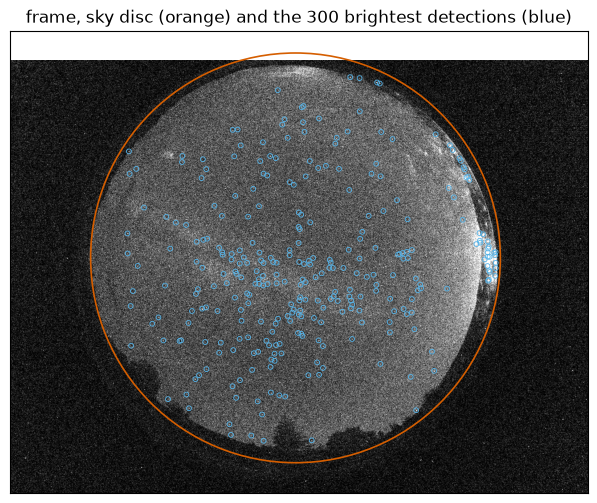

In [2]:
frame = load_frame(IMAGE, tz=TZ, keep_image=True)
print(f"{frame.path.name}: {frame.width}x{frame.height} px, mid-exposure {frame.utc} UTC, exposure {frame.exposure_s} s")
print(f"{len(frame.detections)} detections; sky disc centre ({frame.disc[0]:.0f}, {frame.disc[1]:.0f}), radius {frame.disc[2]:.0f} px")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
small = frame.gray[::4, ::4]
ax.imshow(small, cmap="gray", vmin=np.percentile(small, 5), vmax=np.percentile(small, 99.7), extent=(0, frame.width, frame.height, 0))
ax.add_patch(plt.Circle(frame.disc[:2], frame.disc[2], fill=False, color="#D55E00", lw=1.2))
d = frame.detections
top = d.order[:300]
ax.scatter(d.x[top], d.y[top], s=12, facecolors="none", edgecolors="#56B4E9", linewidths=0.6)
ax.set_title("frame, sky disc (orange) and the 300 brightest detections (blue)")
ax.set_xticks([]); ax.set_yticks([]); plt.show()

## 2. Calibrate

`calibrate` runs the blind pose search and the progressive refinement. The log shows the candidates
of the pose search (image rotation ψ, displacement of the zenith from the disc centre, focal scale),
validated by the number of bright stars that then match a detection, and the three association
stages with their residuals.

In [3]:
result = calibrate([frame], SITE, decentering=False, verbose=True)
model = result.model
summary = result.summary()
print()
print(model)
print(f"total tilt {model.total_tilt:.2f}°, zenith at pixel ({model.zenith_pixel[0]:.0f}, {model.zenith_pixel[1]:.0f}), "
      f"horizon radius {model.horizon_radius:.0f} px, {60/float(model.plate_scale(0)):.2f} arcmin/px on the axis, "
      f"{60/float(model.plate_scale(90)):.2f} arcmin/px at the horizon")
print(f"{summary['n_pairs']} star–detection pairs, median residual {summary['median_px']:.2f} px, "
      f"{100*summary['within_1px']:.0f}% within 1 px, {summary['elapsed_s']} s in total")

sky disc: centre (2004, 1390), radius 1438 px -> f0 = 915 px/rad


  candidate psi 161.0 deg, zenith shift (-115, 70) px, focal x1.12: 19/23 bright coincidences -> 197 pairs of mag <= 4.5 within 12 px


  candidate psi 279.0 deg, zenith shift (60, 0) px, focal x1.20: 10/23 bright coincidences -> 39 pairs of mag <= 4.5 within 12 px


  candidate psi 225.0 deg, zenith shift (-180, 120) px, focal x0.88: 9/23 bright coincidences -> 53 pairs of mag <= 4.5 within 12 px


  candidate psi 291.0 deg, zenith shift (-60, -30) px, focal x0.88: 9/23 bright coincidences -> 30 pairs of mag <= 4.5 within 12 px


...

  stage 0: mag <= 4.5, radius 25 px -> 143 pairs, median 0.59 px, p90 15.54 px


  stage 1: mag <= 5.5, radius 12 px -> 613 pairs, median 0.66 px, p90 8.65 px


  stage 2: mag <= 5.5, radius 7 px -> 581 pairs, median 0.56 px, p90 1.76 px


  final: 547 pairs, median 0.53 px, rms 1.08 px



CameraModel(cx=1948.54, cy=1467.83, f=1005.32 px/rad, psi=161.0569°, tilt=(-1.8272, -3.2787)°, k=[-0.02106, -0.0052])
total tilt 3.75°, zenith at pixel (1884, 1456), horizon radius 1447 px, 3.42 arcmin/px on the axis, 4.99 arcmin/px at the horizon
547 star–detection pairs, median residual 0.53 px, 85% within 1 px, 1.5 s in total


## 3. Look at the result

Catalogue stars projected with the fitted model over the frame, with the altitude circles (0°, 30°, 60°),
the cardinal meridians, the zenith (star) and the optical centre (+). The camera is tilted, so the
zenith does not coincide with the optical centre.

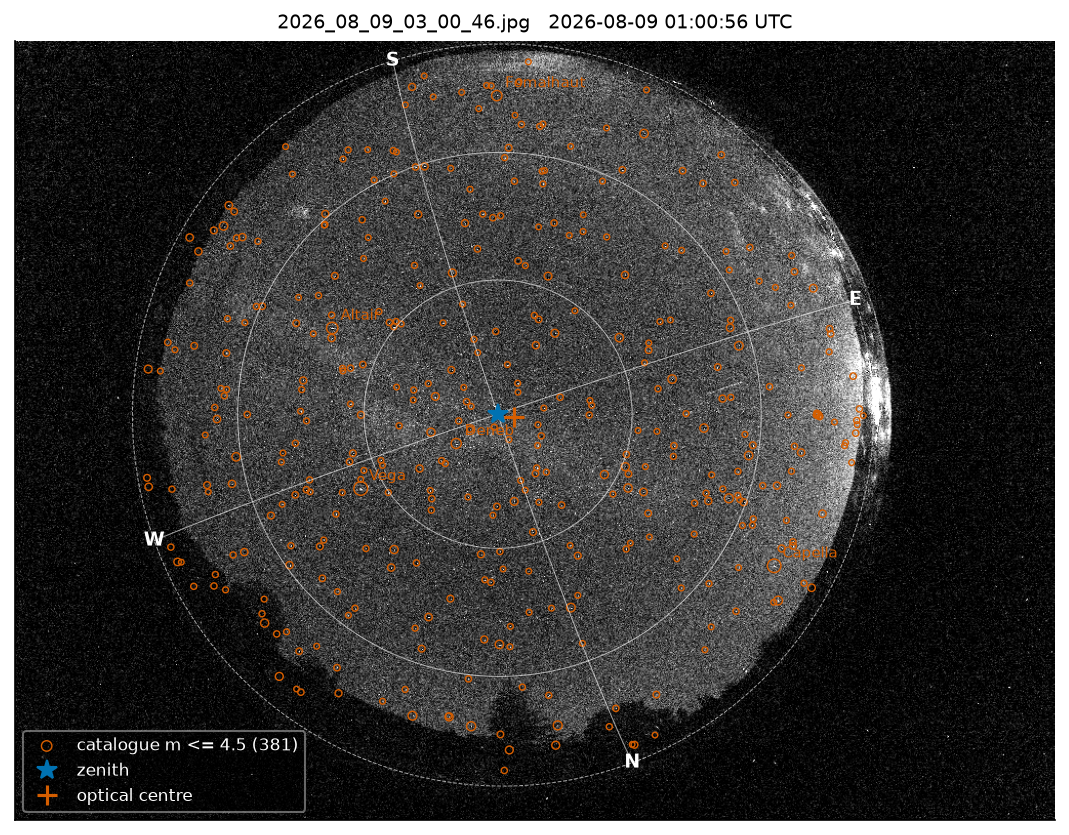

In [4]:
display(Image(plots.overlay(frame, model, SITE, max_mag=4.5)))

Cut-outs around bright stars at low and high altitude: detections (circles) and predicted positions (+).

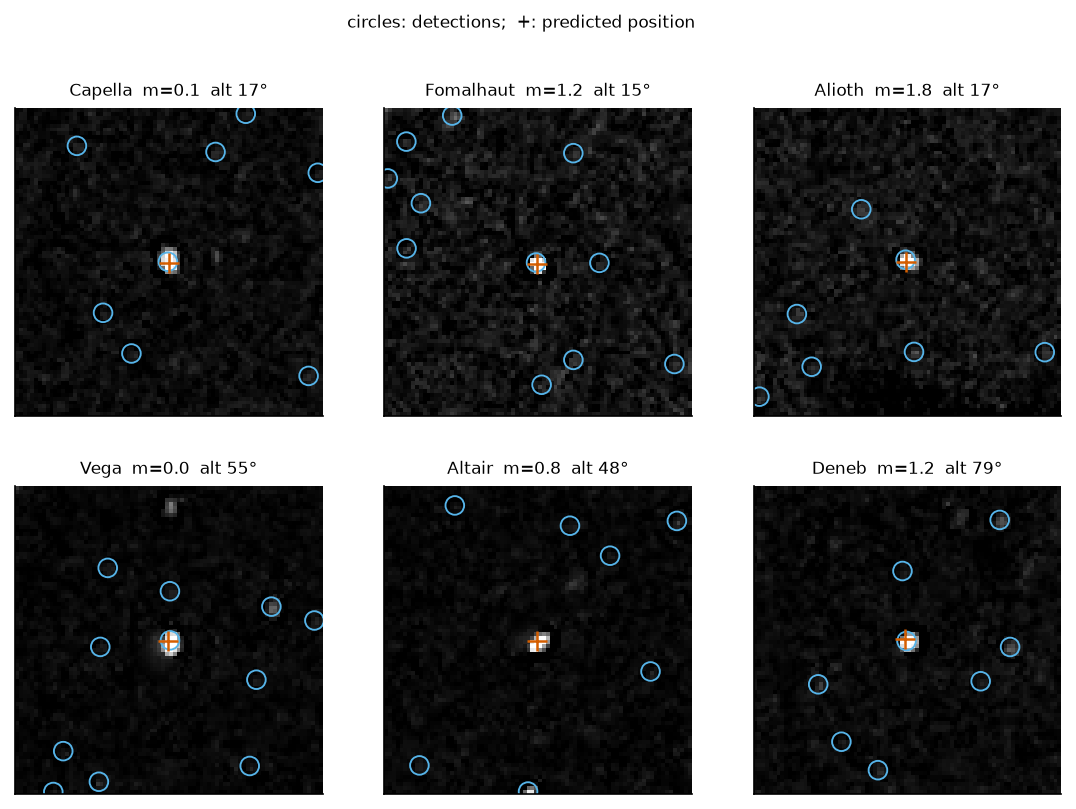

In [5]:
display(Image(plots.cutouts(frame, model, SITE)))

Residuals of the retained pairs against altitude, as vectors on the sensor, and as a histogram.
Sub-pixel agreement over most of the sky is expected; the lowest band (below 10°) is limited by the
detections (extinction, small plate scale, the edge of the disc), not by the model.

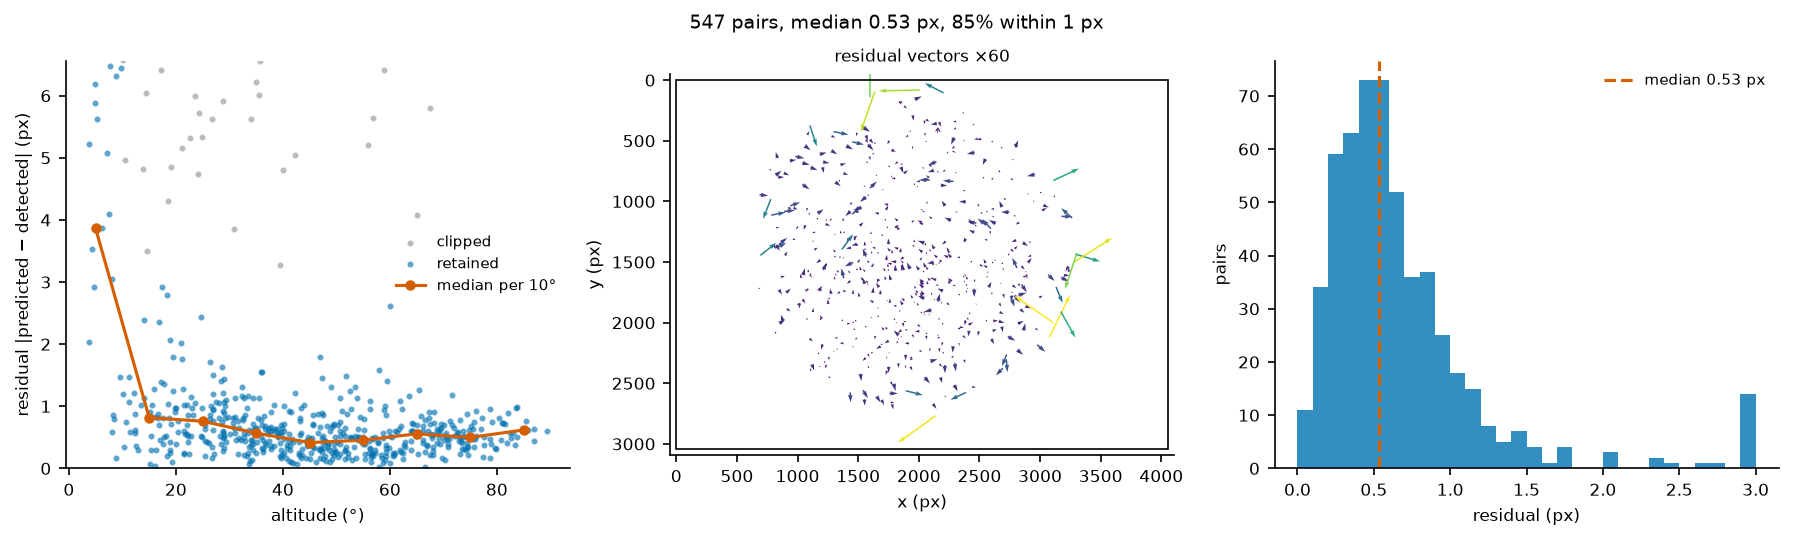

altitude   3-10°:   19 pairs, median 3.86 px, p90 6.35 px, 21% within 1 px
altitude  10-20°:   51 pairs, median 0.82 px, p90 1.80 px, 65% within 1 px
altitude  20-30°:   72 pairs, median 0.76 px, p90 1.39 px, 71% within 1 px
altitude  30-50°:  180 pairs, median 0.47 px, p90 0.93 px, 91% within 1 px
altitude  50-70°:  150 pairs, median 0.49 px, p90 0.95 px, 91% within 1 px
altitude  70-90°:   75 pairs, median 0.52 px, p90 0.82 px, 99% within 1 px
altitude    all°:  547 pairs, median 0.53 px, p90 1.16 px, 85% within 1 px


In [6]:
display(Image(plots.residual_plots(result)))
for b in summary["bands"]:
    if b["n"]:
        print(f"altitude {b['band']:>6}°: {b['n']:4d} pairs, median {b['median']:.2f} px, p90 {b['p90']:.2f} px, {100*b['within_1px']:.0f}% within 1 px")

The radial function compared with the ideal fisheye projections. With `k3 = -0.021` this lens lies
between the equidistant and the equisolid-angle projections; the fitted focal length of ~1005 px/rad
on 1.55 µm pixels is 1.558 mm, against the 1.55 mm of the manufacturer.

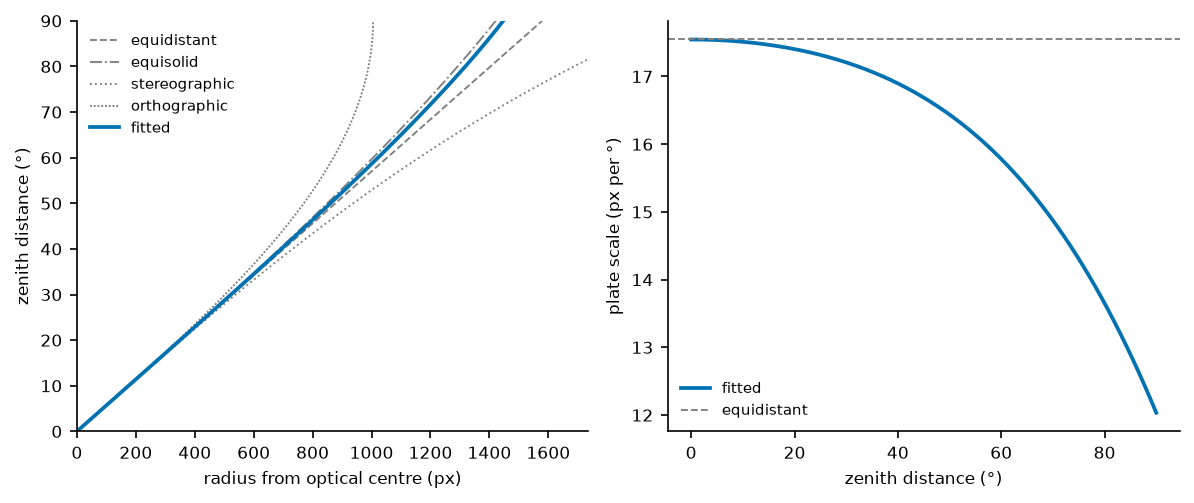

f = 1005.3 px/rad = 1.558 mm for 1.55 µm pixels;  k3 = -0.0211 (0 equidistant, -0.042 equisolid), k5 = -0.0052


In [7]:
display(Image(plots.radial_plot(model)))
print(f"f = {model.f:.1f} px/rad = {model.f * 1.55e-3:.3f} mm for 1.55 µm pixels;  k3 = {model.k[0]:.4f} (0 equidistant, -0.042 equisolid), k5 = {model.k[1]:.4f}")

## 4. Does the calibration transfer to other nights?

The two other frames in `examples/images` come from different nights (one with the Moon up). We
associate their detections with the catalogue using the model fitted above, with **no refitting**,
and look at the residuals.

In [8]:
others = [p for p in sorted(IMAGES.glob("*.jpg")) if p != IMAGE]
for p in others:
    fr = load_frame(p, tz=TZ)
    pairs = evaluate(model, [fr], SITE, max_mag=5.5, radius=10.0)
    d = pairs.residuals(model)
    bright = pairs.mag <= 4.0
    print(f"{p.name}: {len(pairs)} associations, median {np.median(d):.2f} px, {100*np.mean(d < 1):.0f}% within 1 px; "
          f"stars brighter than mag 4: {np.median(d[bright]):.2f} px, {100*np.mean(d[bright] < 1):.0f}% within 1 px")

2026_07_08_01_01_06.jpg: 511 associations, median 0.85 px, 65% within 1 px; stars brighter than mag 4: 0.78 px, 78% within 1 px


2026_07_28_01_00_56.jpg: 167 associations, median 0.67 px, 84% within 1 px; stars brighter than mag 4: 0.60 px, 87% within 1 px


## 5. Save and use the calibration

The model is stored as a small JSON file. `project` converts sky directions to pixels and `unproject`
pixels to sky directions; `solid_angle` gives the steradians covered by each pixel (useful to weight
cloud fraction or sky brightness over the sky).

In [9]:
out = Path.cwd() / "calibration_demo.json"
model.save(out)
print(json.dumps({k: v for k, v in model.to_dict().items() if k != "meta"}, indent=1))

x, y = model.project(np.array([45.0, 10.0]), np.array([0.0, 270.0]))
print("alt 45° az 0° (north) -> pixel", np.round([x[0], y[0]], 1), ";  alt 10° az 270° (west) -> pixel", np.round([x[1], y[1]], 1))
alt, az = model.unproject(np.array([model.width / 2]), np.array([model.height / 2]))
print(f"centre of the sensor -> alt {alt[0]:.2f}°, az {az[0]:.2f}°")
print(f"solid angle per pixel: {model.solid_angle(model.cx, model.cy)*1e6:.2f} µsr on the axis, "
      f"{model.solid_angle(model.cx + 0.95*model.horizon_radius, model.cy)*1e6:.2f} µsr near the horizon")

{
 "model": "kannala-brandt + rigid rotation",
 "cx": 1948.535054412666,
 "cy": 1467.8328490887823,
 "f": 1005.3231434071115,
 "psi": 161.05691498944626,
 "tau_x": -1.8271932795270553,
 "tau_y": -3.278662479443702,
 "k": [
  -0.021064281268616085,
  -0.005196482213800044
 ],
 "p": null,
 "width": 4056,
 "height": 3040,
 "derived": {
  "focal_length_px_per_deg": 17.54619889895322,
  "total_tilt_deg": 3.752947874032576,
  "zenith_pixel": [
   1883.7335666662902,
   1456.1623240972558
  ],
  "horizon_radius_px": 1447.1236105190576,
  "plate_scale_axis_arcmin_per_px": 3.419544047433516,
  "plate_scale_horizon_arcmin_per_px": 4.985519596811356
 }
}
alt 45° az 0° (north) -> pixel [2148.1 2189.6] ;  alt 10° az 270° (west) -> pixel [ 657.5 1902.9]
centre of the sensor -> alt 81.01°, az 47.20°
solid angle per pixel: 0.99 µsr on the axis, 0.97 µsr near the horizon


## Command line and web demo

The same pipeline is available from the shell and from a drag-and-drop web page:

```bash
ascal calibrate examples/images/2026_08_09_03_00_46.jpg --lat 43.259147 --lon -6.60345 --tz Europe/Madrid --out calib.json --report report/
ascal check calib.json examples/images/2026_07_08_01_01_06.jpg --lat 43.259147 --lon -6.60345 --tz Europe/Madrid
ascal web          # then open http://127.0.0.1:8000
```